In [2]:
# Import Libraries 

import pandas as pd 
import numpy as np 


In [3]:
# Load Dataset 

df = pd.read_csv("50_Startups (1).csv")
df.head()


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
# Dataset Information 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [5]:
#Total Null Values 
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [6]:
# Null percentage 

(df.isnull().sum()/len(df))*100


R&D Spend          0.0
Administration     0.0
Marketing Spend    0.0
State              0.0
Profit             0.0
dtype: float64

In [7]:
# Remove Null  Values 

df = df.dropna()
df.shape

(50, 5)

In [8]:
# Duplicate Values 

df.duplicated().sum()

np.int64(0)

In [9]:
# Remove Duplicates 

df = df.drop_duplicates()
df.shape 

(50, 5)

In [ ]:
# Cate]gorical columns 

df.select_dtypes(include="object").columns

C:\Users\Hp\AppData\Local\Temp\ipykernel_17324\1291982193.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['State'], dtype='str')

In [20]:
# hot encoding 

df = pd.get_dummies(df,
columns=['State'],drop_first=True)
df.head()

KeyError: "None of [Index(['State'], dtype='str')] are in the [columns]"

In [12]:
#Correlation Matrix 
df.corr(numeric_only=True)


,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
R&D Spend,1.000000,0.241955,0.724248,0.972900,0.105711,0.039068
Administration,0.241955,1.000000,-0.032154,0.200717,0.010493,0.005145
Marketing Spend,0.724248,-0.032154,1.000000,0.747766,0.205685,-0.033670
Profit,0.972900,0.200717,0.747766,1.000000,0.116244,0.031368
State_Florida,0.105711,0.010493,0.205685,0.116244,1.000000,-0.492366
State_New York,0.039068,0.005145,-0.033670,0.031368,-0.492366,1.000000


In [13]:
#Correlation with profit(DV)

df.corr(numeric_only=True)['Profit'].sort_values(ascending=False)

Profit             1.000000
R&D Spend          0.972900
Marketing Spend    0.747766
Administration     0.200717
State_Florida      0.116244
State_New York     0.031368
Name: Profit, dtype: float64

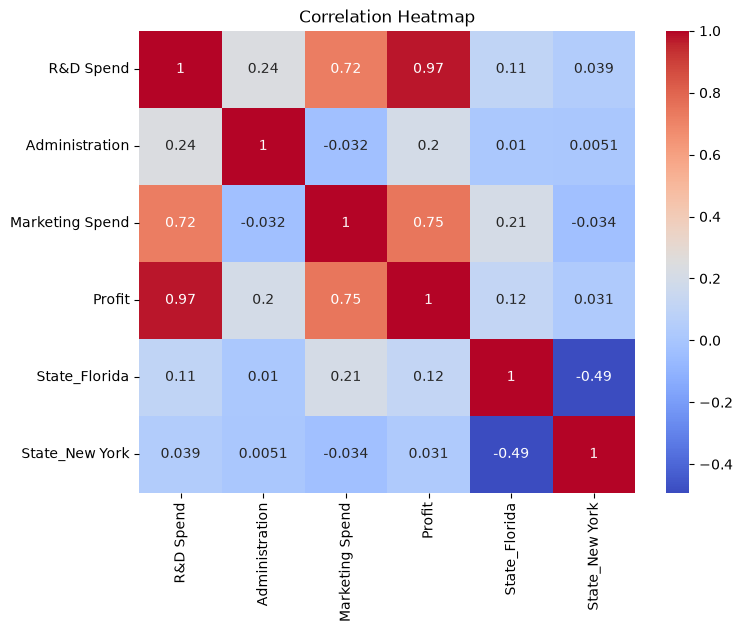

In [14]:
#Heatmap 

import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


In [15]:
#Multicollinearity(VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [16]:
# Independent Variables

X =df.drop("Profit",axis=1)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import pandas as pd 
import numpy as np 

# Independent Variables
X =df.drop("Profit",axis=1)

#Agar stae column abhi bhi hai to hot encoding karo 
X = pd.get_dummies(X,drop_first=True)

#Bhool -> Int 
X  =X.astype(int)

#NaN aur Infinity remove 
X  = X.replace([np.inf,-np.inf],np.nan)
X  = X.dropna()

#VIF 

vif = pd.DataFrame()
vif["Feature"] = X.columns 
vif["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])] 

print(vif)

           Feature       VIF
0        R&D Spend  8.450928
1   Administration  4.950241
2  Marketing Spend  8.092239
3    State_Florida  2.004519
4   State_New York  1.928835


In [18]:
# Final Dataset 

df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [19]:
# Final Shape

df.shape

(50, 6)